In [1]:
# gw-neutral-main.ipynb

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import anndata as ad
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys

In [4]:
in_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/gw-neutral/pp"
out_stat_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/gw-neutral/stats"
out_fig_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/gw-neutral/figures"

In [5]:
utils_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/rs_benchmark/baf/gene/base/scripts"
sys.path.append(utils_dir)
from ubase import *
from ubaf import *
from urdr import stat_stack_zeroprop, stat_LR

In [6]:
os.makedirs(out_stat_dir, exist_ok = True)
os.makedirs(out_fig_dir, exist_ok = True)

In [7]:
cw_prefix = 'cw-'
gw_prefix = 'gw-'

dpi = 300

In [8]:
blue = '#0072B2'
orange = '#E69F00'
green = '#009E73'
red = '#D55E00'     # Vermillion

def_color = blue

In [9]:
tool_labels = ['seed_N', 'stCNASim-rs_N', 'scReadSim-cna_N', 'stCNASim-rs_T', 'scReadSim-cna_T']
tool_palette = {
    'seed_N': orange,
    'stCNASim-rs_N': '#56B4E9',
    'scReadSim-cna_N': green,
    'stCNASim-rs_T': '#F0E442',
    'scReadSim-cna_T': blue
}

# Load Data

In [10]:
seed_normal_fn = os.path.join(in_dir, "seed_normal.h5ad")
rs_normal_fn = os.path.join(in_dir, "rs_normal.h5ad")
rs_tumor_fn = os.path.join(in_dir, "rs_tumor.h5ad")
scrs_normal_fn = os.path.join(in_dir, "scrs_normal.h5ad")
scrs_tumor_fn = os.path.join(in_dir, "scrs_tumor.h5ad")

In [11]:
seed_normal = ad.read_h5ad(seed_normal_fn)
print(seed_normal)

rs_normal = ad.read_h5ad(rs_normal_fn)
print(rs_normal)

rs_tumor = ad.read_h5ad(rs_tumor_fn)
print(rs_tumor)

scrs_normal = ad.read_h5ad(scrs_normal_fn)
print(scrs_normal)

scrs_tumor = ad.read_h5ad(scrs_tumor_fn)
print(scrs_tumor)

AnnData object with n_obs × n_vars = 600 × 27324
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 27324
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 27324
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 27324
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'
AnnData object with n_obs × n_vars = 600 × 27324
    obs: 'cell', 'cell_type'
    var: 'chrom', 'start', 'end', 'feature', 'strand'
    layers: 'A', 'B', 'U'


# Gene-wise Metrics

In [12]:
mv = get_gw_metrics_group(
    adata_lst = [seed_normal, rs_normal, scrs_normal, rs_tumor, scrs_tumor],
    X_names = tool_labels,
    id_lst = [seed_normal.var['feature'].to_numpy(), rs_normal.var['feature'].to_numpy(), scrs_normal.var['feature'].to_numpy(),
             rs_tumor.var['feature'].to_numpy(), scrs_tumor.var['feature'].to_numpy()],
    metrics = ["mean", "var", "cv", "zero_prop", "sum"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,mean_A,var_A,cv_A,zero_prop_A,sum_A,X_name_A,feature_A,mean_B,var_B,cv_B,...,var_ABU,cv_ABU,zero_prop_ABU,sum_ABU,X_name_ABU,feature_ABU,group,feature,DP,baf
0,0.0,0.0,0.0,1.0,0,seed_N,MIR1302-2HG,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,seed_N,MIR1302-2HG,seed_N,MIR1302-2HG,0,NaN
1,0.0,0.0,0.0,1.0,0,seed_N,FAM138A,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,seed_N,FAM138A,seed_N,FAM138A,0,NaN
2,0.0,0.0,0.0,1.0,0,seed_N,OR4F5,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,seed_N,OR4F5,seed_N,OR4F5,0,NaN
3,0.0,0.0,0.0,1.0,0,seed_N,AL627309.1,0.0,0.0,0.0,...,0.001664,24.474475,0.998333,1,seed_N,AL627309.1,seed_N,AL627309.1,0,NaN
4,0.0,0.0,0.0,1.0,0,seed_N,AL627309.3,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,seed_N,AL627309.3,seed_N,AL627309.3,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136615,0.0,0.0,0.0,1.0,0,scReadSim-cna_T,ARRDC1-AS1,0.0,0.0,0.0,...,0.103264,2.966280,0.895000,65,scReadSim-cna_T,ARRDC1-AS1,scReadSim-cna_T,ARRDC1-AS1,0,NaN
136616,0.0,0.0,0.0,1.0,0,scReadSim-cna_T,EHMT1,0.0,0.0,0.0,...,0.226864,2.250247,0.818333,127,scReadSim-cna_T,EHMT1,scReadSim-cna_T,EHMT1,0,NaN
136617,0.0,0.0,0.0,1.0,0,scReadSim-cna_T,AL772363.1,0.0,0.0,0.0,...,0.000000,0.000000,1.000000,0,scReadSim-cna_T,AL772363.1,scReadSim-cna_T,AL772363.1,0,NaN
136618,0.0,0.0,0.0,1.0,0,scReadSim-cna_T,CACNA1B,0.0,0.0,0.0,...,0.001664,24.474475,0.998333,1,scReadSim-cna_T,CACNA1B,scReadSim-cna_T,CACNA1B,0,NaN


In [13]:
tmp = mv.copy()

tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

In [14]:
np.log10(mv['mean_ABU'].min() + 1), np.log10(mv['mean_ABU'].max() + 1)

(0.0, 2.4374704529511626)

In [15]:
np.log10(mv['mean_AB'].min() + 1), np.log10(mv['mean_AB'].max() + 1)

(0.0, 2.204653475148131)

In [16]:
np.log10(mv['DP'].min() + 1), np.log10(mv['DP'].max() + 1)

(0.0, 4.980089767127471)

## Single Metric

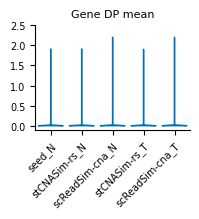

In [17]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['mean_AB']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.5, 1, 1.5, 2, 2.5])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene DP mean", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "DP-mean.png")
fig.savefig(fn, dpi = 300)

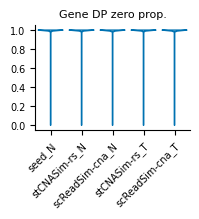

In [18]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv['group']
y = mv['zero_prop_AB']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    inner = None,
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene DP zero prop.", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "DP-zero_prop.png")
fig.savefig(fn, dpi = 300)

### Percentage of genes within specific ranges of zero proportions

In [19]:
st_zeroprop = stat_stack_zeroprop(
    data = mv, 
    metric = "zero_prop_AB",
    group = "group", 
    cutoffs = [.9, .99, 1.01], 
    labels = ["[0, 0.9)", "[0.9, 0.99)", "[0.99, 1]"]
)
print(st_zeroprop)


tmp = st_zeroprop[["group", "cutoff", "label", "percent"]]
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "DP-perc-of-genes-on-zero_prop.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

              group  level_1  cutoff        label    percent
0            seed_N        0    0.90     [0, 0.9)   1.064998
1            seed_N        1    0.99  [0.9, 0.99)   3.615869
2            seed_N        2    1.01    [0.99, 1]  95.319133
3     stCNASim-rs_N        0    0.90     [0, 0.9)   1.061338
4     stCNASim-rs_N        1    0.99  [0.9, 0.99)   3.575611
5     stCNASim-rs_N        2    1.01    [0.99, 1]  95.363051
6   scReadSim-cna_N        0    0.90     [0, 0.9)   1.211389
7   scReadSim-cna_N        1    0.99  [0.9, 0.99)   3.674425
8   scReadSim-cna_N        2    1.01    [0.99, 1]  95.114185
9     stCNASim-rs_T        0    0.90     [0, 0.9)   1.035720
10    stCNASim-rs_T        1    0.99  [0.9, 0.99)   3.590250
11    stCNASim-rs_T        2    1.01    [0.99, 1]  95.374030
12  scReadSim-cna_T        0    0.90     [0, 0.9)   1.204070
13  scReadSim-cna_T        1    0.99  [0.9, 0.99)   3.729322
14  scReadSim-cna_T        2    1.01    [0.99, 1]  95.066608


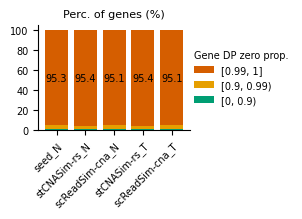

In [20]:
data = st_zeroprop
x, y, hue = 'group', 'percent', 'label'
min_v = 5
font_size = 7
colors = [green, orange, red]

# prepare data.
df = long2wide(data, index = x, columns = hue, values = y)
df[x] = df.index
hue_groups = data[hue].unique()
cumsum = np.array([0.0] * df.shape[0])

# plot.
fig = plt.figure(figsize = (3.1, 2.3))

for i, h in enumerate(hue_groups):
    if i == 0:
        plt.bar(df[x], df[h], label = h, color = colors[i])
    else:
        ax = plt.gca()
        ax.bar(df[x], df[h], label = h, bottom = cumsum, color = colors[i])
    cumsum += df[h]
        
for c in ax.containers:
    labels = [str(round(v.get_height(), 1))    \
                if v.get_height() > min_v else '' for v in c]
    ax.bar_label(c, label_type = 'center', labels = labels, 
                    fontsize = font_size, color = 'black')

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_ylabel("")
ax.set_xlabel("")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles = handles[::-1],
    labels = labels[::-1],
    title = "Gene DP zero prop.",
    loc = 'center left',
    bbox_to_anchor = [0.97, 0.5],
    title_fontsize = font_size,
    fontsize = font_size,
    alignment = 'left',
    frameon = False
)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Perc. of genes (%)", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "DP-perc-of-genes-on-zero_prop.png")
fig.savefig(fn, dpi = 300)

### BAF

In [21]:
mv_ind, idx_ind = remove_nan_baf(mv, how = 'independent')
print(mv_ind)

          mean_A     var_A       cv_A  zero_prop_A  sum_A         X_name_A  \
25      0.010000  0.009900   9.949874     0.990000      6           seed_N   
39      0.093333  0.097956   3.353341     0.913333     56           seed_N   
62      0.006667  0.006622  12.206555     0.993333      4           seed_N   
75      0.006667  0.006622  12.206555     0.993333      4           seed_N   
89      0.085000  0.097775   3.678705     0.925000     51           seed_N   
...          ...       ...        ...          ...    ...              ...   
136544  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
136545  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
136546  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
136564  0.011667  0.011531   9.204036     0.988333      7  scReadSim-cna_T   
136603  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   

         feature_A    mean_B     var_B       cv_B  ...   var_AB

In [22]:
tmp = mv_ind.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "metric_values-filter_nan_independent.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

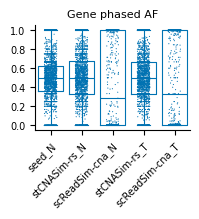

In [23]:
fig = plt.figure(figsize = (2.1, 2.3))

x = mv_ind['group']
y = mv_ind['baf']
ax = sns.boxplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False,
    showfliers = True,
    fliersize = 0.8,
    linewidth = 0.8
)
sns.stripplot(
    x = x, y = y, 
    palette = [def_color] * len(tool_labels), 
    hue = x, 
    legend = False, 
    ax = ax,
    size = 0.8, 
    jitter = 0.2
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    rotation = 45, rotation_mode = "anchor",
    ha = 'right', fontsize = 7
)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(
    ax.get_yticklabels(), 
    fontsize = 7
)
ax.set_xlabel(None)
ax.set_ylabel(None)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.title(r"Gene phased AF", fontsize = 8)

plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "baf.png")
fig.savefig(fn, dpi = 300)

## Linear Regression

In [24]:
pairs = [
    ("stCNASim-rs_N", "seed_N"),
    ("scReadSim-cna_N", "seed_N"),
    ("stCNASim-rs_N", "scReadSim-cna_N"),
    ("stCNASim-rs_T", "scReadSim-cna_T")
]

selected_gvars = pd.DataFrame(data = dict(
    x = [p[1] for p in pairs],
    y = [p[0] for p in pairs],
))

In [25]:
mv_isec, idx_isec = remove_nan_baf(mv, how = 'intersect')
print(mv_isec)


tmp = mv_isec.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "metric_values-filter_nan_intersect.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

          mean_A     var_A       cv_A  zero_prop_A  sum_A         X_name_A  \
25      0.010000  0.009900   9.949874     0.990000      6           seed_N   
39      0.093333  0.097956   3.353341     0.913333     56           seed_N   
62      0.006667  0.006622  12.206555     0.993333      4           seed_N   
75      0.006667  0.006622  12.206555     0.993333      4           seed_N   
89      0.085000  0.097775   3.678705     0.925000     51           seed_N   
...          ...       ...        ...          ...    ...              ...   
136544  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
136545  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
136546  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   
136564  0.011667  0.011531   9.204036     0.988333      7  scReadSim-cna_T   
136603  0.000000  0.000000   0.000000     1.000000      0  scReadSim-cna_T   

         feature_A    mean_B     var_B       cv_B  ...   var_AB

In [26]:
st_lr = stat_LR(
    data = mv_isec,
    metric = "baf", group = "group", gvars = selected_gvars, 
    log_scale = True
)
print(st_lr)

tmp = st_lr.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "baf-lr-stat.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

                 x                y         a         b        r2   p_value
0           seed_N    stCNASim-rs_N  0.981919  0.001431  0.600529  0.000000
1           seed_N  scReadSim-cna_N  0.231328  0.108008  0.010170  0.000011
2  scReadSim-cna_N    stCNASim-rs_N  0.040265  0.164039  0.005313  0.001476
3  scReadSim-cna_T    stCNASim-rs_T  0.044987  0.161761  0.006415  0.000475


In [27]:
df_baf = long2wide(mv_isec, columns = 'group', values = 'baf', index = 'feature')
print(df_baf)

tmp = df_baf.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "baf-lr.tsv"), 
    header = True, 
    index = True, 
    sep = "\t"
)

group         seed_N  stCNASim-rs_N  scReadSim-cna_N  stCNASim-rs_T  \
feature                                                               
AL645608.8  0.000000       0.000000         1.000000       0.000000   
SDF4        0.476636       0.511905         0.000000       0.416667   
ATAD3C      0.333333       0.000000         0.000000       0.000000   
CDK11A      0.333333       0.500000         1.000000       0.500000   
FAAP20      0.592000       0.610619         1.000000       0.596491   
...              ...            ...              ...            ...   
AGPAT2      0.515406       0.498507         0.995316       0.553125   
FAM69B      0.500000       0.800000         1.000000       0.357143   
SNHG7       0.550000       0.578947         1.000000       0.526316   
LCN12       0.333333       0.000000         0.000000       0.000000   
NELFB       0.364486       0.323529         1.000000       0.353535   

group       scReadSim-cna_T  
feature                      
AL645608.8      

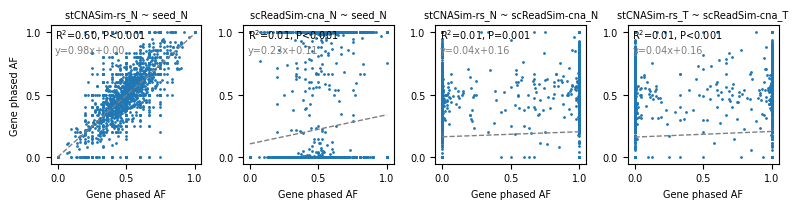

In [28]:
ncols = 4
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (8.0, 2.2))

pos_r = (.03, .9)
pos_fit = (.03, .8)
fit_kws = dict()
fontsize = 7

columns = np.asarray(df_baf.columns)
df = df_baf[columns].copy()

gvars = st_lr[['x', 'y']].copy()
k = 0
for i in range(gvars.shape[0]):
    ax = axs.flat[k]
    cx = gvars['x'].loc[i]
    cy = gvars['y'].loc[i]
    d = st_lr.loc[(st_lr['x'] == cx) & (st_lr['y'] == cy)]
    assert d.shape[0] == 1
    a = d['a'].iloc[0]
    b = d['b'].iloc[0]
    r2 = d['r2'].iloc[0]
    p_value = d['p_value'].iloc[0]

    x, y = df[cx], df[cy]
    ax.plot(x, y, marker = '.', markersize = 2, linestyle = 'none')
    x_vals = np.linspace(max(ax.get_xlim()[0], np.min(x)), 
                        min(ax.get_xlim()[1], np.max(x)), 100)

    color_fit = fit_kws.get('color', 'gray')
    ax.plot(
        x_vals, a*x_vals+b, 
        linestyle = fit_kws.get('linestyle', '--'), 
        color = color_fit, 
        linewidth = fit_kws.get('linewidth', 1.0)
    )
    equation_str = format_equation(a, b)
    ax.annotate(equation_str, xy = pos_fit, xycoords = ax.transAxes,
                color = color_fit, fontsize = fontsize)
    pv_str = format_pvalue(p_value) 
    ax.annotate(r"R$^2$=%.2f, %s" % (r2, pv_str), xy = pos_r, 
                xycoords = ax.transAxes, fontsize = fontsize)

    ax.set_title(None)
    ax.set_xlabel("Gene phased AF", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel("Gene phased AF", fontsize = fontsize)
    ax.set_title(cy + ' ~ ' + cx, fontsize = fontsize)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "baf-lr.png")
fig.savefig(fn, dpi = 300)

### Filter genes by DP

In [29]:
#filter_genes = mv.loc[(mv['group'] == 'seed_N') & (mv['DP'] < 10), 'feature']
#print(filter_genes.shape)

#df = mv.loc[~(mv['feature'].isin(filter_genes))].copy()
#print(df.shape)

#mv_isec_DP, idx_isec_DP = remove_nan_baf(df, how = 'intersect')
#print(mv_isec_DP)

In [30]:
filter_genes = mv_isec.loc[mv_isec['DP'] < 10, 'feature']
print(filter_genes.shape)

df = mv_isec.loc[~(mv_isec['feature'].isin(filter_genes))].copy()
mv_isec_DP, idx_isec_DP = remove_nan_baf(df, how = 'intersect')


tmp = mv_isec_DP.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "metric_values-filter_nan_intersect-filter_DP.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

(4037,)


In [31]:
st_lr_DP = stat_LR(
    data = mv_isec_DP,
    metric = "baf", group = "group", gvars = selected_gvars, 
    log_scale = True
)
print(st_lr_DP)

tmp = st_lr_DP.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "baf-lr-stat-filter_DP.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

                 x                y         a         b        r2  \
0           seed_N    stCNASim-rs_N  1.007961 -0.002328  0.661491   
1           seed_N  scReadSim-cna_N  0.737030  0.026565  0.032510   
2  scReadSim-cna_N    stCNASim-rs_N  0.049293  0.166864  0.026433   
3  scReadSim-cna_T    stCNASim-rs_T  0.045802  0.168766  0.024013   

         p_value  
0  3.388657e-209  
1   6.988015e-08  
2   1.210356e-06  
3   3.771611e-06  


In [32]:
df_baf_DP = long2wide(mv_isec_DP, columns = 'group', values = 'baf', index = 'feature')
print(df_baf_DP)

tmp = df_baf_DP.copy()
tmp.to_csv(
    os.path.join(out_stat_dir, gw_prefix + "baf-lr-filter_DP.tsv"), 
    header = True, 
    index = True, 
    sep = "\t"
)

group       seed_N  stCNASim-rs_N  scReadSim-cna_N  stCNASim-rs_T  \
feature                                                             
SDF4      0.476636       0.511905         0.000000       0.416667   
FAAP20    0.592000       0.610619         1.000000       0.596491   
H6PD      0.153846       0.066667         0.000000       0.058824   
CTNNBIP1  0.619048       0.545455         1.000000       0.687500   
SRM       0.294118       0.333333         1.000000       0.272727   
...            ...            ...              ...            ...   
EGFL7     0.466321       0.472527         0.124260       0.408867   
AGPAT2    0.515406       0.498507         0.995316       0.553125   
FAM69B    0.500000       0.800000         1.000000       0.357143   
SNHG7     0.550000       0.578947         1.000000       0.526316   
NELFB     0.364486       0.323529         1.000000       0.353535   

group     scReadSim-cna_T  
feature                    
SDF4             0.000000  
FAAP20           1

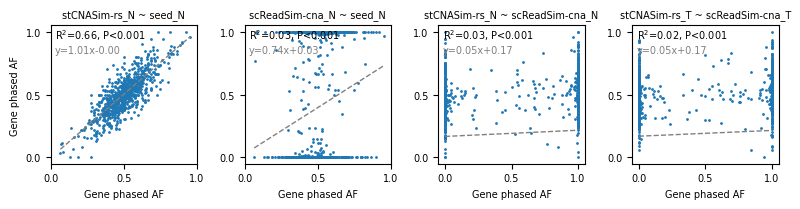

In [33]:
ncols = 4
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (8.0, 2.2))

pos_r = (.03, .9)
pos_fit = (.03, .8)
fit_kws = dict()
fontsize = 7

columns = np.asarray(df_baf_DP.columns)
df = df_baf_DP[columns].copy()

gvars = st_lr_DP[['x', 'y']].copy()
k = 0
for i in range(gvars.shape[0]):
    ax = axs.flat[k]
    cx = gvars['x'].loc[i]
    cy = gvars['y'].loc[i]
    d = st_lr_DP.loc[(st_lr_DP['x'] == cx) & (st_lr_DP['y'] == cy)]
    assert d.shape[0] == 1
    a = d['a'].iloc[0]
    b = d['b'].iloc[0]
    r2 = d['r2'].iloc[0]
    p_value = d['p_value'].iloc[0]

    x, y = df[cx], df[cy]
    ax.plot(x, y, marker = '.', markersize = 2, linestyle = 'none')
    x_vals = np.linspace(max(ax.get_xlim()[0], np.min(x)), 
                        min(ax.get_xlim()[1], np.max(x)), 100)

    color_fit = fit_kws.get('color', 'gray')
    ax.plot(
        x_vals, a*x_vals+b, 
        linestyle = fit_kws.get('linestyle', '--'), 
        color = color_fit, 
        linewidth = fit_kws.get('linewidth', 1.0)
    )
    equation_str = format_equation(a, b)
    ax.annotate(equation_str, xy = pos_fit, xycoords = ax.transAxes,
                color = color_fit, fontsize = fontsize)
    pv_str = format_pvalue(p_value) 
    ax.annotate(r"R$^2$=%.2f, %s" % (r2, pv_str), xy = pos_r, 
                xycoords = ax.transAxes, fontsize = fontsize)

    ax.set_title(None)
    ax.set_xlabel("Gene phased AF", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel("Gene phased AF", fontsize = fontsize)
    ax.set_title(cy + ' ~ ' + cx, fontsize = fontsize)
    ax.set_xticks([0, 0.5, 1])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "baf-lr-filter_DP.png")
fig.savefig(fn, dpi = 300)

### BAF vs. Mean

In [34]:
selected_gvars = ['seed_N', 'stCNASim-rs_N', 'scReadSim-cna_N', 'stCNASim-rs_T', 'scReadSim-cna_T']

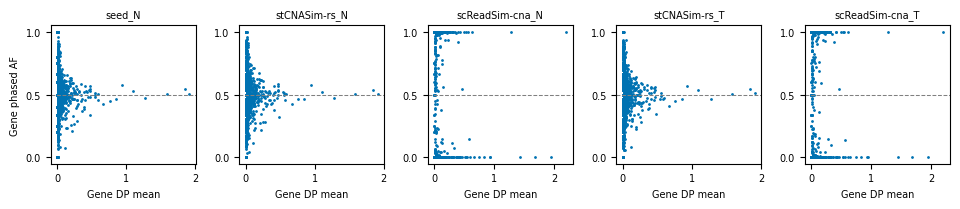

In [35]:
ncols = 5
fig, axs = plt.subplots(nrows = 1, ncols = ncols, figsize = (9.7, 2.2))

fontsize = 7

gvars = selected_gvars
k = 0
for i in range(len(gvars)):
    ax = axs[k]
    cx = gvars[i]
    df = mv_ind.loc[mv_ind['group'] == cx].copy()

    vx = df['mean_AB'].to_numpy()
    vy = df['baf'].to_numpy()
    vx = np.log10(vx + 1)
    
    ax.plot(vx, vy, marker = '.', markersize = 2, 
            linestyle = 'none', color = def_color)

    ref_kws = dict()
    ax.axhline(
        y = ref_kws.get('y', 0.5), 
        linestyle = ref_kws.get('linestyle', '--'), 
        linewidth = ref_kws.get('linewidth', 0.75),
        color = ref_kws.get('color', 'gray')
    )
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(
        ax.get_xticklabels(), 
        fontsize = fontsize
    )
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize
    )
    ax.set_xlabel("Gene DP mean", fontsize = fontsize)
    if k % ncols == 0:
        ax.set_ylabel("Gene phased AF", fontsize = fontsize)
    ax.set_title(cx, fontsize = fontsize)
    k += 1

for ax in axs:
    for s in ["top", "right"]:
        ax.spines[s].set_visible(True)
        
plt.tight_layout()
fn = os.path.join(out_fig_dir, gw_prefix + "baf-vs-DP-mean.png")
fig.savefig(fn, dpi = 300)